### РК2. Вариант 17.
Задание. Для заданного набора данных (по Вашему варианту) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (по варианту для Вашей группы). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [ ]:
# Загрузка данных
data = pd.read_csv("FIFA 2018 Statistics.csv")

# Предварительная обработка данных
def preprocess_data(df):
    # Заполнение пропусков
    df.fillna(0, inplace=True)
    
    # Удаление нерелевантных столбцов
    df = df.drop(["Date", "Own goal Time"], axis=1)
    
    # Создание новых признаков
    df['Total_Shots'] = df['On-Target'] + df['Off-Target']
    df['Shot_Accuracy'] = np.where(df['Total_Shots'] > 0, 
                                 df['On-Target'] / df['Total_Shots'], 0)
    df['Goal_Efficiency'] = np.where(df['On-Target'] > 0, 
                                   df['Goal Scored'] / df['On-Target'], 0)
    
    return df

data = preprocess_data(data)

In [ ]:
# Кодирование категориальных признаков
label_encoders = {}
categorical_cols = ["Team", "Opponent", "Round", "PSO"]
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Кодирование целевой переменной
le_target = LabelEncoder()
data["Man of the Match"] = le_target.fit_transform(data["Man of the Match"])

# Разделение данных
X = data.drop("Man of the Match", axis=1)
y = data["Man of the Match"]

# Проверка дисбаланса классов
print("Class distribution:\n", y.value_counts(normalize=True))

# Разделение на train/test с стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование числовых признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Class distribution:
 Man of the Match
1    0.5
0    0.5
Name: proportion, dtype: float64


In [16]:
# Функция для оценки модели
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    print(f"\n{model_name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    if hasattr(model, "predict_proba"):
        print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


### Модель 1: Дерево решений

In [21]:
dt_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                      dt_params, cv=5, scoring='f1', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
best_dt = dt_grid.best_estimator_

print("\nЛучшие гиперпараметры Дерево решений:", dt_grid.best_params_)
evaluate_model(best_dt, X_test_scaled, y_test, "Decision Tree")


Лучшие гиперпараметры Дерево решений: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree Performance:
Accuracy: 0.6923076923076923
F1-score: 0.75
ROC-AUC: 0.668639053254438

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.46      0.60        13
           1       0.63      0.92      0.75        13

    accuracy                           0.69        26
   macro avg       0.74      0.69      0.68        26
weighted avg       0.74      0.69      0.68        26


Confusion Matrix:
[[ 6  7]
 [ 1 12]]


### Модель 2: Случайный лес


Лучшие гиперпараметры Случайный лес: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Performance:
Accuracy: 0.6153846153846154
F1-score: 0.6875
ROC-AUC: 0.6597633136094674

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.38      0.50        13
           1       0.58      0.85      0.69        13

    accuracy                           0.62        26
   macro avg       0.65      0.62      0.59        26
weighted avg       0.65      0.62      0.59        26


Confusion Matrix:
[[ 5  8]
 [ 2 11]]


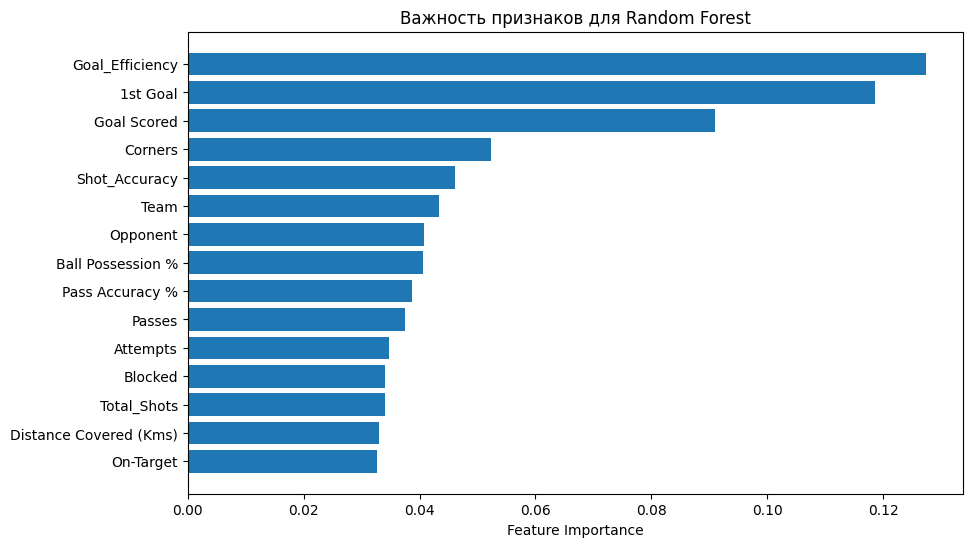

In [22]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', None]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                      rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

print("\nЛучшие гиперпараметры Случайный лес:", rf_grid.best_params_)
evaluate_model(best_rf, X_test_scaled, y_test, "Random Forest")

# Важность признаков для Random Forest
import matplotlib.pyplot as plt

feature_importance = best_rf.feature_importances_
sorted_idx = np.argsort(feature_importance)[-15:] 
pos = np.arange(len(sorted_idx)) + 0.5

plt.figure(figsize=(10, 6))
plt.barh(pos, feature_importance[sorted_idx], align='center')
plt.yticks(pos, X.columns[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Важность признаков для Random Forest')
plt.show()